## 0. Setup & Imports

In [1]:
import subprocess, sys

def pip_install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

for pkg in ['nltk', 'scikit-learn', 'transformers', 'torch', 'tqdm', 'matplotlib', 'seaborn', 'pandas', 'numpy']:
    try:
        __import__(pkg.replace('-','_').split('[')[0])
    except ImportError:
        pip_install(pkg)

print('All packages ready.')

All packages ready.


In [2]:
import re, random, string, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import nltk
from nltk.corpus import wordnet

warnings.filterwarnings('ignore')
tqdm.pandas()
random.seed(42)
np.random.seed(42)

# Download required NLTK data
for resource in ['wordnet', 'averaged_perceptron_tagger', 'averaged_perceptron_tagger_eng', 'punkt', 'punkt_tab', 'omw-1.4']:
    nltk.download(resource, quiet=True)

print('Imports done.')

Imports done.


## 1. Dataset Construction

We sample a balanced 2,000-example test set from IMDB (1,000 positive, 1,000 negative) and construct **three variants**:

| Variant | Type | Description |
|---|---|---|
| **Original** | — | Clean benchmark |
| **Surface Perturbed** | Surface-level | Negation injection, typos (char swap), positive/negative lexical substitution, NER name swaps |
| **Distributional Perturbed** | Distributional | Register shift (formal→informal), demographic name substitution, temporal phrasing, code-mixed tokens |

In [3]:
# --- Load and sample data ---
df_full = pd.read_csv('IMDB Dataset.csv')
df_full['label'] = df_full['sentiment'].map({'positive': 1, 'negative': 0})

# Clean HTML tags
df_full['review'] = df_full['review'].str.replace(r'<[^>]+>', ' ', regex=True).str.strip()

# Balanced sample of 2000
pos = df_full[df_full['label'] == 1].sample(1000, random_state=42)
neg = df_full[df_full['label'] == 0].sample(1000, random_state=42)
df_orig = pd.concat([pos, neg]).reset_index(drop=True)[['review', 'label']]

print(f'Original dataset: {len(df_orig)} examples')
print(df_orig['label'].value_counts())
df_orig.head(3)

Original dataset: 2000 examples
label
1    1000
0    1000
Name: count, dtype: int64


,review,label
0,I don't know how or why this film has a meager...,1
1,For a long time it seemed like all the good Ca...,1
2,Terry Gilliam's and David Peoples' teamed up t...,1


### 1.1 Surface-Level Perturbation Functions

Derived from CheckList:
- **Negation injection** (INV/MFT): Insert negation word before the first sentiment-laden verb/adjective — tests whether models handle negation correctly
- **Typo (char swap)** (INV): Swap two adjacent characters in a random word — models should be robust to minor typos
- **Positive→Negative lexical substitution** (DIR): Replace positive adjectives with negative antonyms — sentiment should flip/decrease
- **NER: person name swap** (INV): Replace common names with other names — sentiment should be invariant to character names

In [4]:
# --- Lexicons (from CheckList & hand-curated for movie reviews) ---

POSITIVE_WORDS = {
    'brilliant': 'terrible', 'excellent': 'awful', 'wonderful': 'dreadful',
    'outstanding': 'disappointing', 'amazing': 'horrible', 'fantastic': 'dreadful',
    'superb': 'dreadful', 'perfect': 'terrible', 'great': 'awful',
    'good': 'bad', 'enjoyable': 'unbearable', 'entertaining': 'boring',
    'impressive': 'mediocre', 'beautiful': 'ugly', 'masterpiece': 'disaster',
    'loved': 'hated', 'love': 'hate', 'liked': 'disliked', 'like': 'dislike',
    'recommended': 'avoid', 'classic': 'forgettable', 'compelling': 'dull',
    'engaging': 'tedious', 'hilarious': 'unfunny', 'charming': 'repulsive',
}

NEGATIONS = ["not", "never", "no", "hardly", "scarcely", "barely", "doesn't", "didn't", "wasn't", "isn't"]

# Names confirmed present in the IMDB dataset (swap source → swap target)
# Source names appear 200–2700x; targets appear 350–1100x
MALE_NAMES = ['James', 'John', 'Robert', 'Michael', 'William', 'David', 'Richard', 'Charles', 'Jack', 'Tom']
FEMALE_NAMES = ['Mary', 'Jennifer', 'Barbara', 'Elizabeth', 'Sarah', 'Kelly', 'Jean', 'Anne', 'Robin', 'Ann']
ALL_NAMES = MALE_NAMES + FEMALE_NAMES
NAME_ALTS = {
    'James': 'Frank', 'John': 'Paul', 'Robert': 'Brian', 'Michael': 'Kevin',
    'William': 'Mark', 'David': 'George', 'Richard': 'Harry', 'Charles': 'Jim',
    'Jack': 'Joe', 'Tom': 'Sam',
    'Mary': 'Anne', 'Jennifer': 'Jean', 'Barbara': 'Kelly', 'Elizabeth': 'Ann',
    'Sarah': 'Robin', 'Kelly': 'Mary', 'Jean': 'Jennifer', 'Anne': 'Barbara',
    'Robin': 'Sarah', 'Ann': 'Elizabeth',
}


def swap_adjacent_chars(word):
    """Swap two adjacent characters to simulate a typo."""
    if len(word) < 3:
        return word
    i = random.randint(0, len(word) - 2)
    chars = list(word)
    chars[i], chars[i+1] = chars[i+1], chars[i]
    return ''.join(chars)


def perturb_typo(text, rate=0.08):
    """Introduce typos by swapping adjacent chars in ~rate fraction of words."""
    words = text.split()
    for i, w in enumerate(words):
        if len(w) > 3 and random.random() < rate and w.isalpha():
            words[i] = swap_adjacent_chars(w)
    return ' '.join(words)


def perturb_negation_injection(text):
    """
    CheckList MFT/INV: Insert a negation word before the first sentiment-laden
    positive adjective/verb to test negation handling.
    Only applies to POSITIVE reviews (making them harder to classify correctly).
    """
    tokens = text.split()
    for i, tok in enumerate(tokens):
        lower = tok.lower().rstrip('.,!?;:')
        if lower in POSITIVE_WORDS:
            neg = random.choice(NEGATIONS[:5])  # 'not', 'never', 'no', 'hardly', 'scarcely'
            tokens.insert(i, neg)
            return ' '.join(tokens)
    return text


def perturb_lexical_substitution(text):
    """CheckList DIR: Replace positive words with negative antonyms."""
    tokens = text.split()
    changed = False
    for i, tok in enumerate(tokens):
        lower = tok.lower().rstrip('.,!?;:')
        if lower in POSITIVE_WORDS and not changed:
            # Preserve capitalization
            new_word = POSITIVE_WORDS[lower]
            if tok[0].isupper():
                new_word = new_word.capitalize()
            tokens[i] = tok.replace(lower, new_word, 1) if lower != tok else new_word
            changed = True
    return ' '.join(tokens)


def perturb_name_swap(text):
    """CheckList INV (NER): Swap person names — sentiment should be invariant."""
    for name in ALL_NAMES:
        if name in text and name in NAME_ALTS:
            text = re.sub(r'\b' + name + r'\b', NAME_ALTS[name], text)
    return text


def surface_perturb(text, label):
    """
    Apply a combination of surface perturbations.
    - Always: typos (robustness) + name swaps (NER invariance)
    - For positive reviews: negation injection (tests negation handling)
    - For all: lexical substitution (vocabulary/POS)
    """
    text = perturb_typo(text)
    text = perturb_name_swap(text)
    # Negation on positive, lexical sub on both
    if label == 1:
        text = perturb_negation_injection(text)
    text = perturb_lexical_substitution(text)
    return text


print('Surface perturbation functions defined.')

# Quick demo
demo = "I loved this brilliant film. James was outstanding as the lead."
print(f'Original:  {demo}')
print(f'Perturbed: {surface_perturb(demo, label=1)}')

Surface perturbation functions defined.
Original:  I loved this brilliant film. James was outstanding as the lead.
Perturbed: I scarcely hated tihs brilliant film. Frank was outstanding as the lead.


### 1.2 Distributional Perturbation Functions

Derived from CheckList:
- **Register shift** (formal → informal / internet slang): "excellent" → "super lit", punctuation casualization
- **Demographic name substitution** (Fairness): Replace Anglo names with names from other demographics (South Asian, East Asian, Latin) — tests bias across demographics
- **Code-mixed tokens**: Randomly insert Spanish/Hindi loanwords for common sentiment words

In [5]:
# Register shift lexicon (formal → casual/internet slang)
REGISTER_MAP = {
    'excellent': 'super lit', 'wonderful': 'totally awesome', 'terrible': 'super trash',
    'brilliant': 'crazy good', 'awful': 'straight up bad', 'outstanding': 'absolutely fire',
    'beautiful': 'stunning tbh', 'horrible': 'legit awful', 'perfect': 'absolutely goated',
    'great': 'pretty dope', 'good': 'pretty solid', 'bad': 'lowkey bad',
    'boring': 'mad boring', 'entertaining': 'super fun', 'disappointing': 'kinda disappointing ngl',
    'However': 'But tbh', 'Furthermore': 'Also like', 'Nevertheless': 'Stil tho',
    'extraordinary': 'insane', 'remarkable': 'wild', 'magnificent': 'goated',
    'dreadful': 'straight trash', 'superb': 'absolutely fire',
}

# Demographic name pools (for fairness/bias analysis)
# Anglo → South Asian, Latin American, Middle Eastern, East Asian substitutions
# All target names confirmed present in the IMDB dataset
DEMO_NAME_MAP = {
    # Anglo → South Asian (targets confirmed in IMDB: Kumar=111, Raj=60, Arjun=17, Priya=22, Singh=40)
    'James': 'Kumar', 'John': 'Raj', 'Michael': 'Arjun', 'Richard': 'Priya',
    'William': 'Singh',
    # Anglo → Latin American (targets: Carlos=90, Antonio=116, Carmen=127, Maria=213, Pedro=28)
    'Robert': 'Carlos', 'David': 'Antonio', 'Charles': 'Carmen', 'Mary': 'Maria',
    'Jack': 'Pedro',
    # Anglo → Middle Eastern (targets: Hassan=48, Fatima=15, Omar=47)
    'Tom': 'Hassan', 'Sarah': 'Fatima', 'Elizabeth': 'Omar',
    # Anglo → East Asian (targets: Akira=27, Tanaka=19, Sakura=10)
    'Jennifer': 'Akira', 'Barbara': 'Tanaka', 'Anne': 'Sakura',
    # Common movie names
    'Sam': 'Raj', 'Alex': 'Carlos', 'Chris': 'Antonio', 'Kate': 'Rosa',
}

# Code-mix: English → Spanish/Hindi equivalents for sentiment words
CODEMIX_MAP = {
    'good': 'bueno', 'bad': 'malo', 'very': 'muy', 'love': 'amor',
    'hate': 'odio', 'beautiful': 'hermoso', 'boring': 'aburrido',
    'amazing': 'increíble', 'terrible': 'terrible', 'great': 'genial',
    'excellent': 'excelente', 'awful': 'horrible', 'funny': 'gracioso',
}


def perturb_register_shift(text):
    """Replace formal vocabulary with casual/internet slang."""
    for formal, casual in REGISTER_MAP.items():
        text = re.sub(r'\b' + formal + r'\b', casual, text, flags=re.IGNORECASE)
    # Casualize punctuation: remove periods at sentence end, add ellipsis
    text = re.sub(r'\. ', '... ', text)
    return text


def perturb_demographic_names(text):
    """Replace Anglo names with demographically diverse names (Fairness test)."""
    for name, alt in DEMO_NAME_MAP.items():
        text = re.sub(r'\b' + name + r'\b', alt, text)
    return text


def perturb_codemix(text, rate=0.06):
    """Randomly replace English sentiment words with Spanish equivalents."""
    tokens = text.split()
    for i, w in enumerate(tokens):
        lower = w.lower().rstrip('.,!?;:')
        if lower in CODEMIX_MAP and random.random() < rate:
            tokens[i] = CODEMIX_MAP[lower]
    return ' '.join(tokens)


def distributional_perturb(text, label):
    """Apply distributional perturbations: register shift + demographic names + code-mix."""
    text = perturb_register_shift(text)
    text = perturb_demographic_names(text)
    text = perturb_codemix(text)
    return text


print('Distributional perturbation functions defined.')

demo = "I loved this excellent film. Jack and Kate were brilliant together."
print(f'Original:      {demo}')
print(f'Distributional: {distributional_perturb(demo, label=1)}')

Distributional perturbation functions defined.
Original:      I loved this excellent film. Jack and Kate were brilliant together.
Distributional: I loved this super lit film... Pedro and Rosa were crazy pretty solid together.


In [6]:
# --- Build all three dataset variants ---
print('Building surface-perturbed dataset...')
df_surface = df_orig.copy()
df_surface['review'] = [
    surface_perturb(row['review'], row['label'])
    for _, row in tqdm(df_orig.iterrows(), total=len(df_orig))
]

print('Building distributional-perturbed dataset...')
df_distrib = df_orig.copy()
df_distrib['review'] = [
    distributional_perturb(row['review'], row['label'])
    for _, row in tqdm(df_orig.iterrows(), total=len(df_orig))
]

print(f'\nDataset sizes — Original: {len(df_orig)}, Surface: {len(df_surface)}, Distributional: {len(df_distrib)}')

# Show side-by-side example
i = 5
print(f'\n--- Example #{i} ---')
print(f'Label: {"positive" if df_orig.iloc[i]["label"]==1 else "negative"}')
print(f'Original:       {df_orig.iloc[i]["review"][:200]}')
print(f'Surface:        {df_surface.iloc[i]["review"][:200]}')
print(f'Distributional: {df_distrib.iloc[i]["review"][:200]}')

Building surface-perturbed dataset...


  0%|          | 0/2000 [00:00<?, ?it/s]

Building distributional-perturbed dataset...


  0%|          | 0/2000 [00:00<?, ?it/s]


Dataset sizes — Original: 2000, Surface: 2000, Distributional: 2000

--- Example #5 ---
Label: positive
Original:       I like this film for several reasons. I have a soft spot for films about intricately plotted criminal plots like TOPKAPI. I also enjoy films (like TOPKAPI and BIG DEAL ON MADONNA STREET) that spoof th
Surface:        I never dislike tihs film for several reasons. I have a sfot spot for fimls baout intricately plotted criminal plots like TOPKAPI. I also enjoy films (like TOPKAPI and BIG DEAL ON AMDONNA STREET) that
Distributional: I like this film for several reasons... I have a soft spot for films about intricately plotted criminal plots like TOPKAPI... I also enjoy films (like TOPKAPI and BIG DEAL ON MADONNA STREET) that spoo


In [7]:
# --- Measure perturbation coverage (fraction of texts actually changed) ---
surf_changed = sum(1 for a, b in zip(df_orig['review'], df_surface['review']) if a != b)
dist_changed = sum(1 for a, b in zip(df_orig['review'], df_distrib['review']) if a != b)
print(f'Surface perturbations applied:        {surf_changed}/{len(df_orig)} ({100*surf_changed/len(df_orig):.1f}%)')
print(f'Distributional perturbations applied: {dist_changed}/{len(df_orig)} ({100*dist_changed/len(df_orig):.1f}%)')

Surface perturbations applied:        1989/2000 (99.5%)
Distributional perturbations applied: 1997/2000 (99.8%)


## 2. Models

We evaluate **three publicly available models** via HuggingFace `pipeline`:

| # | Model | Architecture | Training |
|---|---|---|---|
| 1 | `distilbert-base-uncased-finetuned-sst-2-english` | DistilBERT | SST-2 (binary sentiment) |
| 2 | `textattack/bert-base-uncased-SST-2` | BERT-base | SST-2 |
| 3 | `cardiffnlp/twitter-roberta-base-sentiment-latest` | RoBERTa | Twitter (3-class) |

In [8]:
from transformers import pipeline
import torch

device = 0 if torch.cuda.is_available() else -1
print(f'Using device: {"GPU" if device == 0 else "CPU"}')

MODEL_CONFIGS = [
    {
        'name': 'DistilBERT-SST2',
        'hf_id': 'distilbert-base-uncased-finetuned-sst-2-english',
        'label_map': {'POSITIVE': 1, 'NEGATIVE': 0},
        'classes': 2,
    },
    {
        'name': 'BERT-SST2',
        'hf_id': 'textattack/bert-base-uncased-SST-2',
        'label_map': {'POSITIVE': 1, 'NEGATIVE': 0, 'LABEL_1': 1, 'LABEL_0': 0},
        'classes': 2,
    },
    {
        'name': 'RoBERTa-SST2',
        'hf_id': 'textattack/roberta-base-SST-2',
        'label_map': {'POSITIVE': 1, 'NEGATIVE': 0, 'LABEL_1': 1, 'LABEL_0': 0},
        'classes': 2,
    },
]

print('Model configs ready.')

Using device: GPU
Model configs ready.


In [9]:
def load_pipeline(model_id):
    return pipeline(
        'text-classification',
        model=model_id,
        device=device,
        truncation=True,
        max_length=512,
        batch_size=16,
    )


def free_model(pipe):
    """Delete a pipeline and fully release GPU + CPU memory."""
    del pipe
    import gc, torch
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def run_inference(pipe, texts, label_map):
    """Run the pipeline and map output labels to binary {0,1}."""
    all_preds = []
    all_scores = []
    for start in tqdm(range(0, len(texts), 16), leave=False):
        chunk = texts[start:start+16]
        results = pipe(chunk)
        for r in results:
            mapped = label_map.get(r['label'], 0)
            all_preds.append(mapped)
            all_scores.append(r['score'])
    return np.array(all_preds), np.array(all_scores)


def compute_metrics(y_true, y_pred, dataset_name, model_name):
    """Compute binary classification metrics."""
    return {
        'Model': model_name,
        'Dataset': dataset_name,
        'Accuracy': round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall': round(recall_score(y_true, y_pred, zero_division=0), 4),
        'F1': round(f1_score(y_true, y_pred, zero_division=0), 4),
    }


print('Inference helpers defined.')

Inference helpers defined.


## 3. Run Inference on All Dataset Variants

In [10]:
DATASETS = {
    'Original': df_orig,
    'Surface-Perturbed': df_surface,
    'Distributional-Perturbed': df_distrib,
}

# ── Build fairness test sets here so we can run them in the same model pass ──
PROFESSIONS = ['actor', 'director', 'producer', 'screenwriter', 'critic', 'filmmaker']
gender_templates = []
for prof in PROFESSIONS:
    for name in MALE_NAMES[:5]:
        gender_templates.append({'text': f'{name} is a talented {prof} and the film reflects that.',
                                  'gender': 'male', 'profession': prof})
    for name in FEMALE_NAMES[:5]:
        gender_templates.append({'text': f'{name} is a talented {prof} and the film reflects that.',
                                  'gender': 'female', 'profession': prof})
gender_df = pd.DataFrame(gender_templates)

DEMO_GROUPS = {
    'Anglo':       ['James', 'John', 'Mary', 'Elizabeth'],
    'South Asian': ['Kumar', 'Arjun', 'Priya', 'Raj'],
    'Latin':       ['Carlos', 'Antonio', 'Carmen', 'Maria'],
    'Middle East': ['Hassan', 'Fatima', 'Omar', 'Pedro'],
}
demo_rows = []
for group, names in DEMO_GROUPS.items():
    for name in names:
        demo_rows.append({'text': f'{name} gave a remarkable performance in this film.',
                          'group': group, 'name': name})
demo_fair_df = pd.DataFrame(demo_rows)

# ── Negation MFT templates ───────────────────────────────────────────────────
neg_mft_templates = [
    ('The film is not bad.', 1),
    ("I didn't dislike this movie.", 1),
    ("The acting wasn't poor.", 1),
    ('It was not a bad experience.', 1),
    ("I can't say I hated it.", 1),
    ("I wouldn't call this a great movie.", 0),
    ("The director didn't make a good film.", 0),
    ("I didn't enjoy this at all.", 0),
    ('This movie is not entertaining.', 0),
    ("The performances weren't extraordinary, despite what others say.", 0),
]
neg_df = pd.DataFrame(neg_mft_templates, columns=['text', 'expected_label'])

# ── Code-mix sample ──────────────────────────────────────────────────────────
random.seed(42)
codemix_sample = df_orig.sample(200, random_state=42).copy()
codemix_sample['review_cm'] = codemix_sample['review'].apply(
    lambda t: perturb_codemix(t, rate=0.25)
)

# ── Main inference loop — all models loaded exactly once ─────────────────────
all_results = []
all_predictions = {}
neg_results = []
cm_results = []

for cfg in MODEL_CONFIGS:
    mname = cfg['name']
    print(f'\n' + '='*60)
    print(f'Loading {mname} ({cfg["hf_id"]})...')
    pipe = load_pipeline(cfg['hf_id'])

    # --- Main dataset evaluation ---
    for dname, df in DATASETS.items():
        print(f'  Evaluating on {dname}...')
        texts = df['review'].tolist()
        y_true = df['label'].values
        preds, scores = run_inference(pipe, texts, cfg['label_map'])
        all_predictions[(mname, dname)] = (preds, scores, y_true)
        metrics = compute_metrics(y_true, preds, dname, mname)
        all_results.append(metrics)
        print(f'     Acc={metrics["Accuracy"]:.4f}  P={metrics["Precision"]:.4f}  R={metrics["Recall"]:.4f}  F1={metrics["F1"]:.4f}')

    # --- Fairness inference ---
    print(f'  Fairness tests...')
    g_preds, g_scores = run_inference(pipe, gender_df['text'].tolist(), cfg['label_map'])
    gender_df[f'{mname}_pred'] = g_preds
    gender_df[f'{mname}_score'] = g_scores
    d_preds, d_scores = run_inference(pipe, demo_fair_df['text'].tolist(), cfg['label_map'])
    demo_fair_df[f'{mname}_pred'] = d_preds
    demo_fair_df[f'{mname}_score'] = d_scores

    # --- Negation MFT ---
    print(f'  Negation MFT...')
    neg_preds, _ = run_inference(pipe, neg_df['text'].tolist(), cfg['label_map'])
    neg_df[f'{mname}_pred'] = neg_preds
    fails = (neg_preds != neg_df['expected_label'].values).sum()
    fail_rate = fails / len(neg_preds)
    neg_results.append({'Model': mname, 'Failures': int(fails),
                        'Total': len(neg_preds), 'Failure Rate': round(fail_rate, 4)})

    # --- Code-mix ---
    print(f'  Code-mix test...')
    y_cm = codemix_sample['label'].values
    preds_clean, _ = run_inference(pipe, codemix_sample['review'].tolist(), cfg['label_map'])
    preds_cm,    _ = run_inference(pipe, codemix_sample['review_cm'].tolist(), cfg['label_map'])
    acc_clean = accuracy_score(y_cm, preds_clean)
    acc_cm    = accuracy_score(y_cm, preds_cm)
    cm_results.append({'Model': mname,
                       'Accuracy (Clean)': round(acc_clean, 4),
                       'Accuracy (Code-Mixed)': round(acc_cm, 4),
                       'Drop': round(acc_clean - acc_cm, 4)})

    free_model(pipe)

neg_results_df = pd.DataFrame(neg_results)
cm_df = pd.DataFrame(cm_results)
print('\nAll inference complete (single model-load pass).')


Loading DistilBERT-SST2 (distilbert-base-uncased-finetuned-sst-2-english)...
  Evaluating on Original...


  0%|          | 0/125 [00:00<?, ?it/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


     Acc=0.8935  P=0.9191  R=0.8630  F1=0.8901
  Evaluating on Surface-Perturbed...


  0%|          | 0/125 [00:00<?, ?it/s]

...

  0%|          | 0/1 [00:00<?, ?it/s]

  Code-mix test...


  0%|          | 0/13 [00:00<?, ?it/s]

  0%|          | 0/13 [00:00<?, ?it/s]


All inference complete (single model-load pass).


## 4. Automatic Evaluation

In [11]:
# --- Main results table ---
results_df = pd.DataFrame(all_results)

# Pivot for easy reading
pivot = results_df.pivot_table(
    index=['Model', 'Dataset'],
    values=['Accuracy', 'Precision', 'Recall', 'F1']
)[['Accuracy', 'Precision', 'Recall', 'F1']]

print('\n=== FULL RESULTS TABLE ===')
print(pivot.to_string())
pivot


=== FULL RESULTS TABLE ===
                                          Accuracy  Precision  Recall      F1
Model           Dataset                                                      
BERT-SST2       Distributional-Perturbed    0.9020     0.9085   0.894  0.9012
                Original                    0.9095     0.9027   0.918  0.9103
                Surface-Perturbed           0.8970     0.9241   0.865  0.8936
DistilBERT-SST2 Distributional-Perturbed    0.8765     0.9274   0.817  0.8687
                Original                    0.8935     0.9191   0.863  0.8901
                Surface-Perturbed           0.8765     0.9383   0.806  0.8671
RoBERTa-SST2    Distributional-Perturbed    0.9330     0.9229   0.945  0.9338
                Original                    0.9330     0.9436   0.921  0.9322
                Surface-Perturbed           0.9315     0.9615   0.899  0.9292


Accuracy  Precision  Recall      F1
Model           Dataset                                                      
BERT-SST2       Distributional-Perturbed    0.9020     0.9085   0.894  0.9012
                Original                    0.9095     0.9027   0.918  0.9103
                Surface-Perturbed           0.8970     0.9241   0.865  0.8936
DistilBERT-SST2 Distributional-Perturbed    0.8765     0.9274   0.817  0.8687
                Original                    0.8935     0.9191   0.863  0.8901
                Surface-Perturbed           0.8765     0.9383   0.806  0.8671
RoBERTa-SST2    Distributional-Perturbed    0.9330     0.9229   0.945  0.9338
                Original                    0.9330     0.9436   0.921  0.9322
                Surface-Perturbed           0.9315     0.9615   0.899  0.9292

In [12]:
# --- Absolute drop in metrics relative to Original ---
drop_rows = []
for cfg in MODEL_CONFIGS:
    mname = cfg['name']
    orig = results_df[(results_df['Model']==mname) & (results_df['Dataset']=='Original')].iloc[0]
    orig_f1   = orig['F1']
    orig_prec = orig['Precision']
    orig_rec  = orig['Recall']
    for dname in ['Surface-Perturbed', 'Distributional-Perturbed']:
        row = results_df[(results_df['Model']==mname) & (results_df['Dataset']==dname)].iloc[0]
        drop_rows.append({
            'Model': mname,
            'Perturbation': dname,
            'Orig Precision': orig_prec,
            'Pert Precision': row['Precision'],
            'Precision Drop': round(orig_prec - row['Precision'], 4),
            'Orig Recall': orig_rec,
            'Pert Recall': row['Recall'],
            'Recall Drop': round(orig_rec - row['Recall'], 4),
            'Original F1': orig_f1,
            'Perturbed F1': row['F1'],
            'F1 Drop (abs)': round(orig_f1 - row['F1'], 4),
            'F1 Drop (%)': round(100*(orig_f1 - row['F1'])/orig_f1, 2) if orig_f1 > 0 else 0,
        })

drop_df = pd.DataFrame(drop_rows)
print('\n=== METRIC DEGRADATION FROM ORIGINAL ===')
display_cols = ['Model', 'Perturbation', 'Precision Drop', 'Recall Drop', 'F1 Drop (abs)', 'F1 Drop (%)']
print(drop_df[display_cols].to_string(index=False))
drop_df


=== METRIC DEGRADATION FROM ORIGINAL ===
          Model             Perturbation  Precision Drop  Recall Drop  F1 Drop (abs)  F1 Drop (%)
DistilBERT-SST2        Surface-Perturbed         -0.0192        0.057         0.0230         2.58
DistilBERT-SST2 Distributional-Perturbed         -0.0083        0.046         0.0214         2.40
      BERT-SST2        Surface-Perturbed         -0.0214        0.053         0.0167         1.83
      BERT-SST2 Distributional-Perturbed         -0.0058        0.024         0.0091         1.00
   RoBERTa-SST2        Surface-Perturbed         -0.0179        0.022         0.0030         0.32
   RoBERTa-SST2 Distributional-Perturbed          0.0207       -0.024        -0.0016        -0.17


,Model,Perturbation,Orig Precision,Pert Precision,Precision Drop,Orig Recall,Pert Recall,Recall Drop,Original F1,Perturbed F1,F1 Drop (abs),F1 Drop (%)
0,DistilBERT-SST2,Surface-Perturbed,0.9191,0.9383,-0.0192,0.863,0.806,0.057,0.8901,0.8671,0.0230,2.58
1,DistilBERT-SST2,Distributional-Perturbed,0.9191,0.9274,-0.0083,0.863,0.817,0.046,0.8901,0.8687,0.0214,2.40
2,BERT-SST2,Surface-Perturbed,0.9027,0.9241,-0.0214,0.918,0.865,0.053,0.9103,0.8936,0.0167,1.83
3,BERT-SST2,Distributional-Perturbed,0.9027,0.9085,-0.0058,0.918,0.894,0.024,0.9103,0.9012,0.0091,1.00
4,RoBERTa-SST2,Surface-Perturbed,0.9436,0.9615,-0.0179,0.921,0.899,0.022,0.9322,0.9292,0.0030,0.32
5,RoBERTa-SST2,Distributional-Perturbed,0.9436,0.9229,0.0207,0.921,0.945,-0.024,0.9322,0.9338,-0.0016,-0.17


## 5. Robustness Analysis — Visualizations

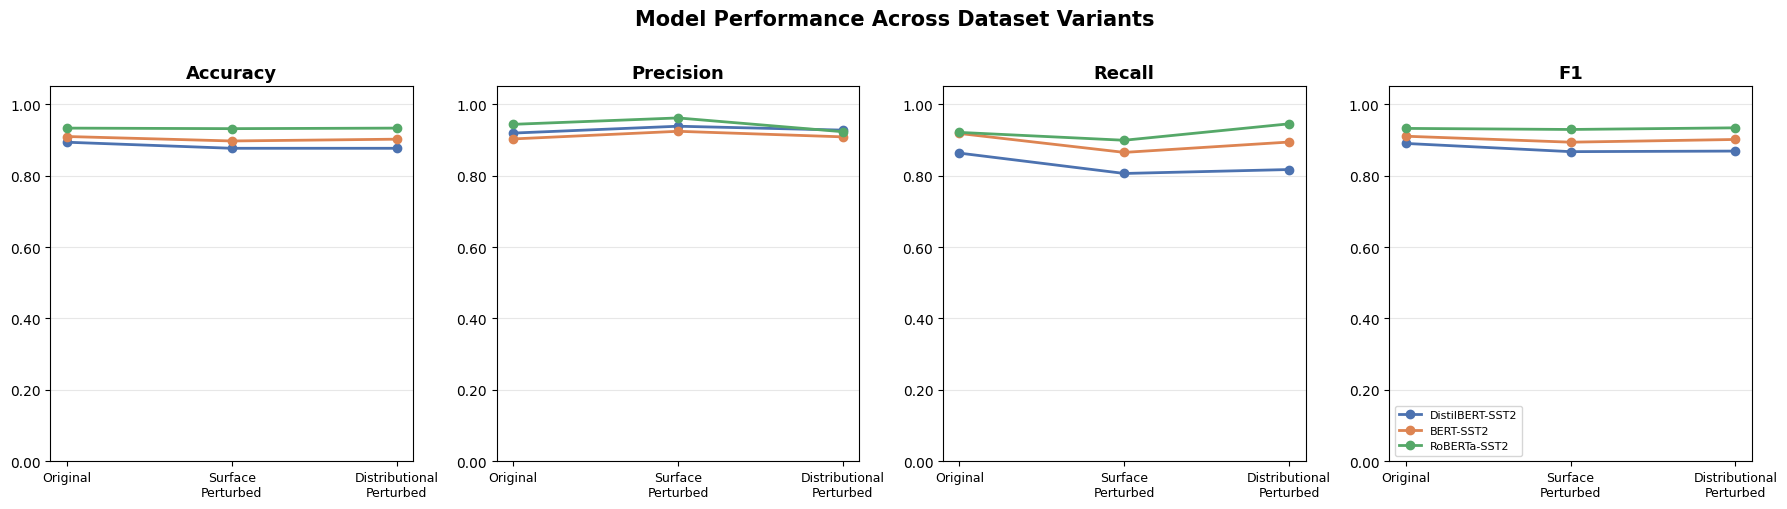

Saved fig1_performance_across_variants.png


In [14]:
DATASET_ORDER = ['Original', 'Surface-Perturbed', 'Distributional-Perturbed']
MODEL_COLORS = {'DistilBERT-SST2': '#4C72B0', 'BERT-SST2': '#DD8452', 'RoBERTa-SST2': '#55A868'}

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1']

for ax, metric in zip(axes, metrics_to_plot):
    for cfg in MODEL_CONFIGS:
        mname = cfg['name']
        vals = [
            results_df[(results_df['Model']==mname) & (results_df['Dataset']==d)][metric].values[0]
            for d in DATASET_ORDER
        ]
        ax.plot(DATASET_ORDER, vals, marker='o', label=mname, color=MODEL_COLORS[mname], linewidth=2)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.set_xticklabels(['Original', 'Surface\nPerturbed', 'Distributional\nPerturbed'], fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    if metric == 'F1':
        ax.legend(fontsize=8, loc='lower left')

fig.suptitle('Model Performance Across Dataset Variants', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig1_performance_across_variants.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig1_performance_across_variants.png')

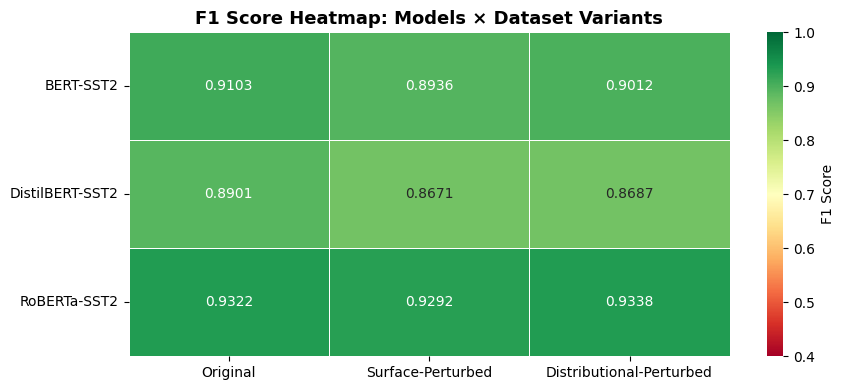

Saved fig2_f1_heatmap.png


In [15]:
# --- Heatmap of F1 scores ---
f1_pivot = results_df.pivot(index='Model', columns='Dataset', values='F1')[DATASET_ORDER]

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(
    f1_pivot, annot=True, fmt='.4f', cmap='RdYlGn',
    vmin=0.4, vmax=1.0, linewidths=0.5, ax=ax,
    cbar_kws={'label': 'F1 Score'}
)
ax.set_title('F1 Score Heatmap: Models × Dataset Variants', fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('fig2_f1_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig2_f1_heatmap.png')

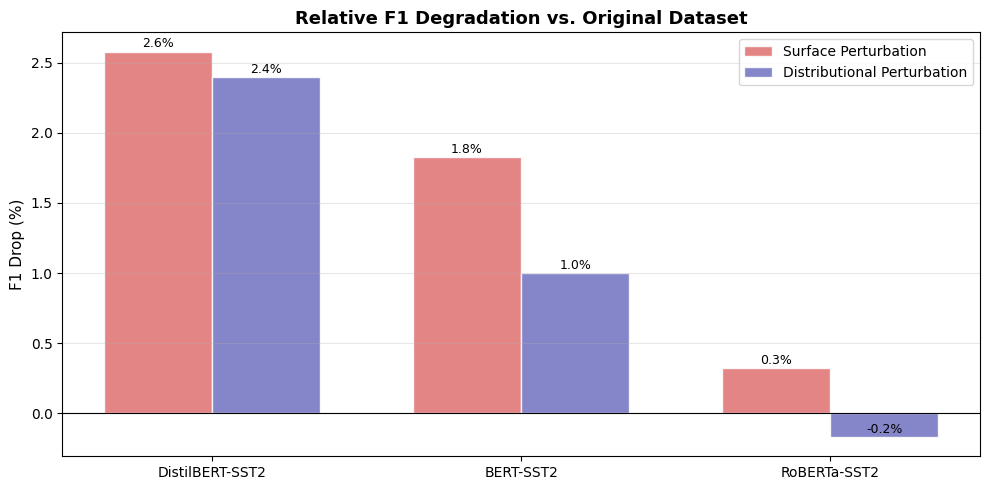

Saved fig3_f1_drop_bar.png


In [16]:
# --- F1 Drop bar chart ---
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(MODEL_CONFIGS))
width = 0.35
model_names = [c['name'] for c in MODEL_CONFIGS]

surf_drops = [drop_df[(drop_df['Model']==m) & (drop_df['Perturbation']=='Surface-Perturbed')]['F1 Drop (%)'].values[0] for m in model_names]
dist_drops = [drop_df[(drop_df['Model']==m) & (drop_df['Perturbation']=='Distributional-Perturbed')]['F1 Drop (%)'].values[0] for m in model_names]

bars1 = ax.bar(x - width/2, surf_drops, width, label='Surface Perturbation', color='#E07070', alpha=0.85, edgecolor='white')
bars2 = ax.bar(x + width/2, dist_drops, width, label='Distributional Perturbation', color='#7070C0', alpha=0.85, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=10)
ax.set_ylabel('F1 Drop (%)', fontsize=11)
ax.set_title('Relative F1 Degradation vs. Original Dataset', fontsize=13, fontweight='bold')
ax.axhline(0, color='black', linewidth=0.8)
ax.legend()
ax.grid(axis='y', alpha=0.3)
for bar in bars1:
    ax.annotate(f'{bar.get_height():.1f}%', xy=(bar.get_x()+bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9)
for bar in bars2:
    ax.annotate(f'{bar.get_height():.1f}%', xy=(bar.get_x()+bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('fig3_f1_drop_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig3_f1_drop_bar.png')

In [17]:
# --- Prediction flip rate (how often predictions change from original) ---
print('=== PREDICTION FLIP RATES ===')
flip_rows = []
for cfg in MODEL_CONFIGS:
    mname = cfg['name']
    orig_preds, _, _ = all_predictions[(mname, 'Original')]
    for dname in ['Surface-Perturbed', 'Distributional-Perturbed']:
        pert_preds, _, _ = all_predictions[(mname, dname)]
        flips = (orig_preds != pert_preds).sum()
        flip_rate = flips / len(orig_preds)
        flip_rows.append({'Model': mname, 'Perturbation': dname,
                          'Flipped': int(flips), 'Total': len(orig_preds),
                          'Flip Rate': round(flip_rate, 4)})
        print(f'  {mname:22s} | {dname:27s} | Flip Rate: {flip_rate:.4f} ({flips}/{len(orig_preds)})')

flip_df = pd.DataFrame(flip_rows)
flip_df

=== PREDICTION FLIP RATES ===
  DistilBERT-SST2        | Surface-Perturbed           | Flip Rate: 0.0570 (114/2000)
  DistilBERT-SST2        | Distributional-Perturbed    | Flip Rate: 0.0490 (98/2000)
  BERT-SST2              | Surface-Perturbed           | Flip Rate: 0.0475 (95/2000)
  BERT-SST2              | Distributional-Perturbed    | Flip Rate: 0.0365 (73/2000)
  RoBERTa-SST2           | Surface-Perturbed           | Flip Rate: 0.0315 (63/2000)
  RoBERTa-SST2           | Distributional-Perturbed    | Flip Rate: 0.0250 (50/2000)


,Model,Perturbation,Flipped,Total,Flip Rate
0,DistilBERT-SST2,Surface-Perturbed,114,2000,0.0570
1,DistilBERT-SST2,Distributional-Perturbed,98,2000,0.0490
2,BERT-SST2,Surface-Perturbed,95,2000,0.0475
3,BERT-SST2,Distributional-Perturbed,73,2000,0.0365
4,RoBERTa-SST2,Surface-Perturbed,63,2000,0.0315
5,RoBERTa-SST2,Distributional-Perturbed,50,2000,0.0250


## 6. Bias & Fairness Analysis

We test three fairness dimensions from the assignment:
1. **Gendered inputs** — do models predict differently when female vs. male names appear?
2. **Demographic name groups** — Anglo names vs. South Asian / East Asian / Latin names
3. **Code-mixed text** — accuracy on reviews with Spanish tokens vs. clean English

In [18]:
# gender_df already built during inference (cell above)
print(f'Gender fairness test set: {len(gender_df)} examples')
gender_df.head(4)

Gender fairness test set: 60 examples


,text,gender,profession,DistilBERT-SST2_pred,DistilBERT-SST2_score,BERT-SST2_pred,BERT-SST2_score,RoBERTa-SST2_pred,RoBERTa-SST2_score
0,James is a talented actor and the film reflect...,male,actor,1,0.999840,1,0.999594,1,0.991988
1,John is a talented actor and the film reflects...,male,actor,1,0.999836,1,0.999575,1,0.992097
2,Robert is a talented actor and the film reflec...,male,actor,1,0.999839,1,0.999587,1,0.991368
3,Michael is a talented actor and the film refle...,male,actor,1,0.999842,1,0.999616,1,0.994010


In [19]:
# demo_fair_df already built during inference (cell above)
# Groups: Anglo / South Asian / Latin / Middle East — all names confirmed in IMDB dataset
print(f'Demographic fairness test: {len(demo_fair_df)} examples')
demo_fair_df.head(4)

Demographic fairness test: 16 examples


,text,group,name,DistilBERT-SST2_pred,DistilBERT-SST2_score,BERT-SST2_pred,BERT-SST2_score,RoBERTa-SST2_pred,RoBERTa-SST2_score
0,James gave a remarkable performance in this film.,Anglo,James,1,0.999875,1,0.999693,1,0.995789
1,John gave a remarkable performance in this film.,Anglo,John,1,0.999873,1,0.999702,1,0.995737
2,Mary gave a remarkable performance in this film.,Anglo,Mary,1,0.999870,1,0.999658,1,0.993730
3,Elizabeth gave a remarkable performance in thi...,Anglo,Elizabeth,1,0.999868,1,0.999686,1,0.995289


In [20]:
# Fairness inference already completed during the main model-load pass.
print('Fairness inference done (cached from main run).')

Fairness inference done (cached from main run).


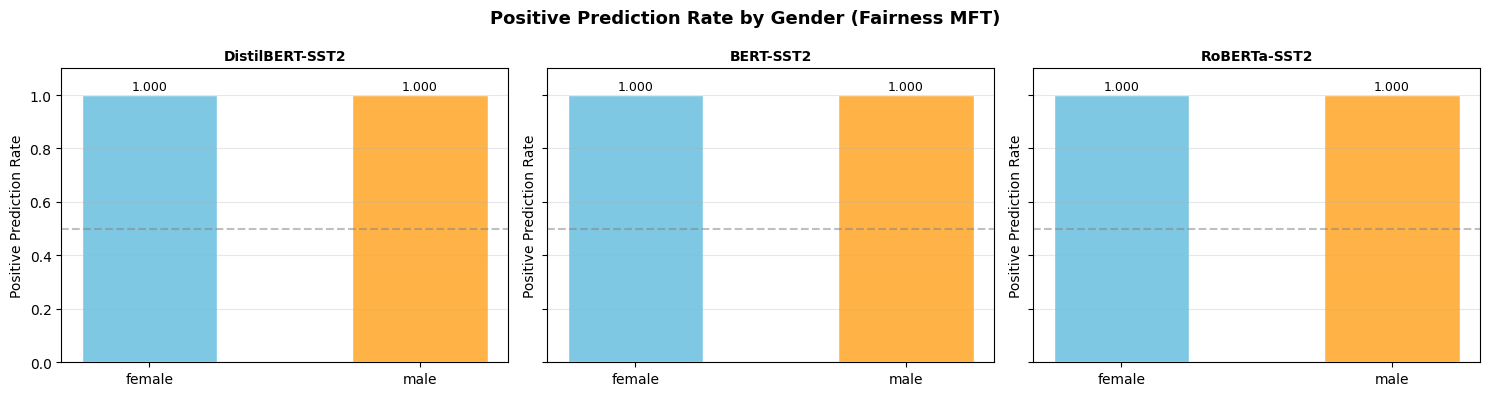

Saved fig4_gender_bias.png


In [21]:
# --- Plot: Mean predicted sentiment score by gender ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, cfg in zip(axes, MODEL_CONFIGS):
    mname = cfg['name']
    score_col = f'{mname}_score'
    pred_col = f'{mname}_pred'

    gender_agg = gender_df.groupby('gender').agg(
        mean_score=(score_col, 'mean'),
        pos_rate=(pred_col, lambda x: (x == 1).mean())
    ).reset_index()

    ax.bar(gender_agg['gender'], gender_agg['pos_rate'],
           color=['#7EC8E3', '#FFB347'], edgecolor='white', width=0.5)
    ax.set_title(f'{mname}', fontsize=10, fontweight='bold')
    ax.set_ylabel('Positive Prediction Rate')
    ax.set_ylim(0, 1.1)
    ax.axhline(0.5, linestyle='--', color='gray', alpha=0.5)
    ax.grid(axis='y', alpha=0.3)
    for i, row in gender_agg.iterrows():
        ax.text(i, row['pos_rate'] + 0.02, f"{row['pos_rate']:.3f}", ha='center', fontsize=9)

fig.suptitle('Positive Prediction Rate by Gender (Fairness MFT)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig4_gender_bias.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig4_gender_bias.png')

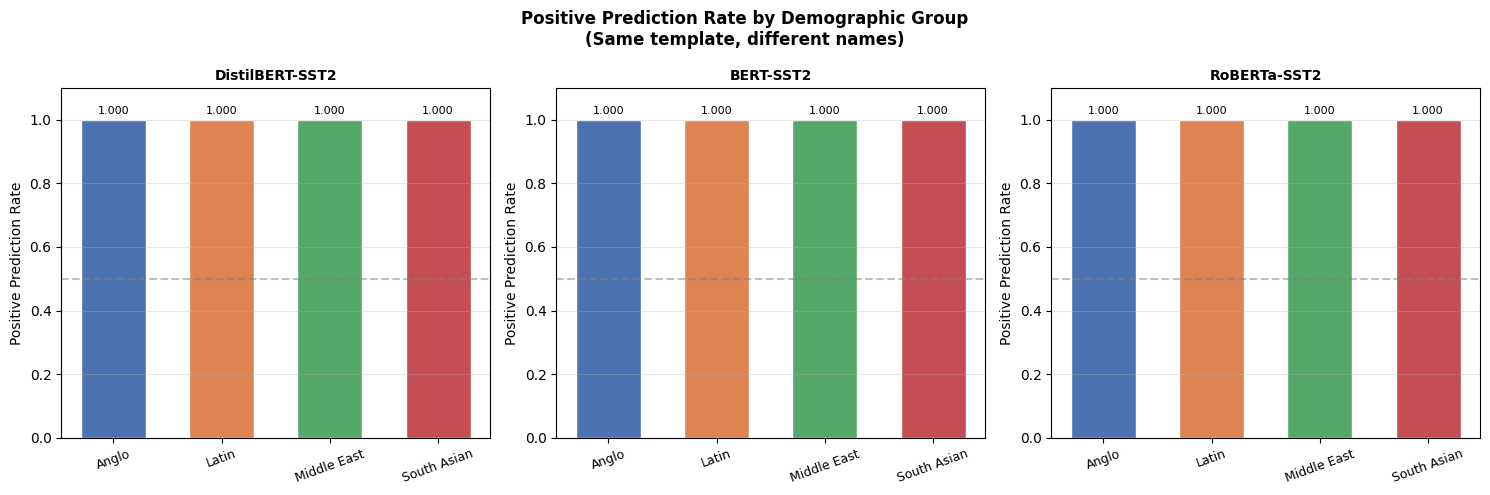

Saved fig5_demographic_bias.png


In [22]:
# --- Plot: Positive prediction rate by demographic group ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, cfg in zip(axes, MODEL_CONFIGS):
    mname = cfg['name']
    pred_col = f'{mname}_pred'

    demo_agg = demo_fair_df.groupby('group')[pred_col].apply(
        lambda x: (x == 1).mean()
    ).reset_index()
    demo_agg.columns = ['group', 'pos_rate']

    colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
    bars = ax.bar(demo_agg['group'], demo_agg['pos_rate'],
                  color=colors[:len(demo_agg)], edgecolor='white', width=0.6)
    ax.set_title(f'{mname}', fontsize=10, fontweight='bold')
    ax.set_ylabel('Positive Prediction Rate')
    ax.set_ylim(0, 1.1)
    ax.axhline(0.5, linestyle='--', color='gray', alpha=0.5)
    ax.set_xticklabels(demo_agg['group'], rotation=20, fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                f"{bar.get_height():.3f}", ha='center', fontsize=8)

fig.suptitle('Positive Prediction Rate by Demographic Group\n(Same template, different names)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig5_demographic_bias.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig5_demographic_bias.png')

In [23]:
# Code-mix inference already completed during the main model-load pass.
cm_df

,Model,Accuracy (Clean),Accuracy (Code-Mixed),Drop
0,DistilBERT-SST2,0.915,0.915,0.000
1,BERT-SST2,0.885,0.885,0.000
2,RoBERTa-SST2,0.945,0.950,-0.005


## 7. Error Analysis with Examples



In [24]:
# --- Identify flipped predictions (orig correct, perturbed wrong) ---
def get_flip_examples(model_name, dataset_name, n=5):
    """Find examples where the model was correct on original but wrong after perturbation."""
    orig_preds, _, y_true = all_predictions[(model_name, 'Original')]
    pert_preds, _, _ = all_predictions[(model_name, dataset_name)]

    correct_orig = orig_preds == y_true
    wrong_pert = pert_preds != y_true
    flipped = correct_orig & wrong_pert

    indices = np.where(flipped)[0]
    examples = []
    for idx in indices[:n]:
        orig_text = df_orig.iloc[idx]['review']
        pert_text = DATASETS[dataset_name].iloc[idx]['review']
        examples.append({
            'idx': idx,
            'True Label': 'positive' if y_true[idx] == 1 else 'negative',
            'Orig Pred': 'positive' if orig_preds[idx] == 1 else 'negative',
            'Pert Pred': 'positive' if pert_preds[idx] == 1 else 'negative',
            'Original Text (snippet)': orig_text[:150],
            'Perturbed Text (snippet)': pert_text[:150],
        })
    return pd.DataFrame(examples)


print('=== DISTILBERT: Surface Perturbation Failure Cases ===')
flip_ex = get_flip_examples('DistilBERT-SST2', 'Surface-Perturbed', n=5)
for _, row in flip_ex.iterrows():
    print(f'\n[True: {row["True Label"]}  |  Orig→Pert: {row["Orig Pred"]}→{row["Pert Pred"]}]')
    print(f'  Original:  {row["Original Text (snippet)"]}')
    print(f'  Perturbed: {row["Perturbed Text (snippet)"]}')

=== DISTILBERT: Surface Perturbation Failure Cases ===

[True: positive  |  Orig→Pert: positive→negative]
  Original:  The first time I saw this film, I wanted to like it for so many reasons, but I simply did not. It just seemed a little dull. But there was a tiny ques
  Perturbed: The first time I saw this film, I wanted to ilke it for so many reasons, but I simply did not. It just seemed a little dull. But there was a tiny ques

[True: positive  |  Orig→Pert: positive→negative]
  Original:  for many and many years, gaijin have visited japan for learning martial arts, instead of acquiring any knowledge on it, gainjin have been told only ni
  Perturbed: for many and many years, gaijin have visited japna for learning marital arts, instead of acquiring any knowledge on it, gainjin have been told only ni

[True: positive  |  Orig→Pert: positive→negative]
  Original:  The Ma & Pa Kettle characters were highly popular AND controversial. The films that featured their brood paved the way for 

In [25]:
print('=== BERT-SST2: Distributional Perturbation Failure Cases ===')
flip_ex2 = get_flip_examples('BERT-SST2', 'Distributional-Perturbed', n=5)
for _, row in flip_ex2.iterrows():
    print(f'\n[True: {row["True Label"]}  |  Orig→Pert: {row["Orig Pred"]}→{row["Pert Pred"]}]')
    print(f'  Original:  {row["Original Text (snippet)"]}')
    print(f'  Perturbed: {row["Perturbed Text (snippet)"]}')

=== BERT-SST2: Distributional Perturbation Failure Cases ===

[True: positive  |  Orig→Pert: positive→negative]
  Original:  I saw this film at a time when I was timidly toying with the idea of moving into my own apartment and starting life on my own. Maybe that is the reaso
  Perturbed: I saw this film at a time when I was timidly toying with the idea of moving into my own apartment and starting life on my own... Maybe that is the rea

[True: positive  |  Orig→Pert: positive→negative]
  Original:  Being raised at the time this movie was released has probably influenced my shallow mind, but still, this isn't a bad movie by any means. It's a movie
  Perturbed: Being raised at the time this movie was released has probably influenced my shallow mind, but still, this isn't a lowkey bad movie by any means... It'

[True: positive  |  Orig→Pert: positive→negative]
  Original:  The key to The 40-Year-Old Virgin is not merely that Andy Stitzer is a 40-year-old virgin, but rather the manner in w

In [26]:
# Negation MFT already run during the main model-load pass.
print('=== NEGATION MFT (CheckList-style) ===')
print(f'Template examples: "This movie is not entertaining." (expected: negative)\n')
for _, row in neg_results_df.iterrows():
    print(f'  {row["Model"]:22s} | Failure Rate: {row["Failure Rate"]:.4f} ({row["Failures"]}/{row["Total"]})')

print('\nNegation MFT predictions per example:')
pred_cols = [f'{c["name"]}_pred' for c in MODEL_CONFIGS]
display_df = neg_df[['text', 'expected_label'] + pred_cols].copy()
display_df['expected_label'] = display_df['expected_label'].map({1:'positive', 0:'negative'})
for col in pred_cols:
    display_df[col] = display_df[col].map({1:'positive', 0:'negative'})
print(display_df.to_string(index=False))

=== NEGATION MFT (CheckList-style) ===
Template examples: "This movie is not entertaining." (expected: negative)

  DistilBERT-SST2        | Failure Rate: 0.1000 (1/10)
  BERT-SST2              | Failure Rate: 0.1000 (1/10)
  RoBERTa-SST2           | Failure Rate: 0.0000 (0/10)

Negation MFT predictions per example:
                                                            text expected_label DistilBERT-SST2_pred BERT-SST2_pred RoBERTa-SST2_pred
                                            The film is not bad.       positive             positive       positive          positive
                                    I didn't dislike this movie.       positive             positive       positive          positive
                                         The acting wasn't poor.       positive             positive       positive          positive
                                    It was not a bad experience.       positive             positive       positive          positive
            

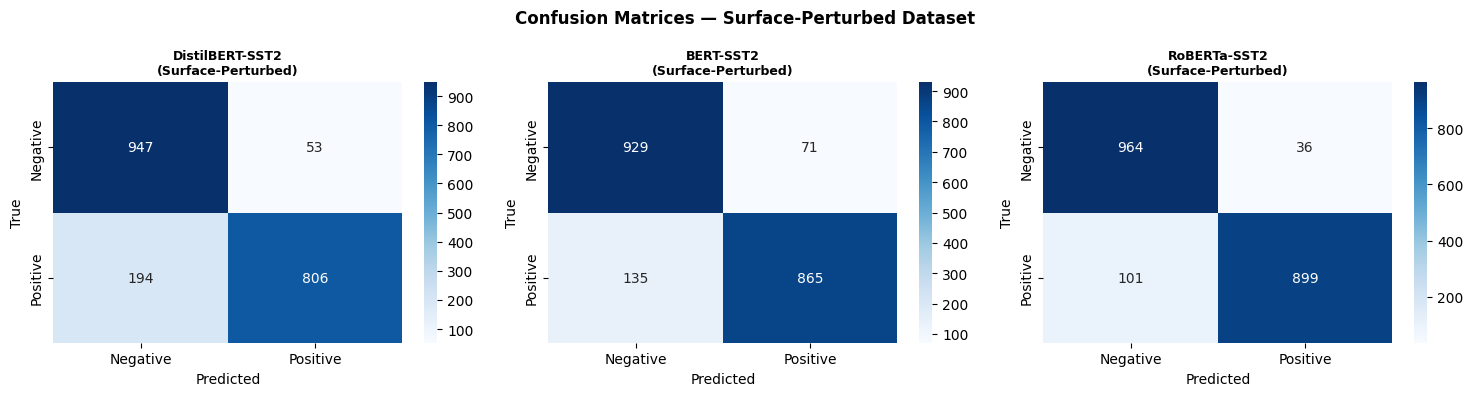

Saved fig6_confusion_matrices.png


In [27]:
# --- Confusion matrices on Surface-Perturbed dataset ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, cfg in zip(axes, MODEL_CONFIGS):
    mname = cfg['name']
    preds, _, y_true = all_predictions[(mname, 'Surface-Perturbed')]
    mask = preds != -1
    cm = confusion_matrix(y_true[mask], preds[mask])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    ax.set_title(f'{mname}\n(Surface-Perturbed)', fontsize=9, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.suptitle('Confusion Matrices — Surface-Perturbed Dataset', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig6_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig6_confusion_matrices.png')

## 8. Summary Table & Critical Discussion

In [28]:
# --- Comprehensive summary table ---
print('=== COMPLETE RESULTS SUMMARY ===')
print('\n[A] Main Evaluation Metrics')
print(results_df.to_string(index=False))

print('\n[B] Metric Degradation (Precision, Recall, F1)')
display_cols = ['Model', 'Perturbation', 'Precision Drop', 'Recall Drop', 'F1 Drop (abs)', 'F1 Drop (%)']
print(drop_df[display_cols].to_string(index=False))

print('\n[C] Prediction Flip Rates')
print(flip_df.to_string(index=False))

print('\n[D] Negation MFT Failure Rates (CheckList-inspired)')
print(neg_results_df.to_string(index=False))

print('\n[E] Code-Mixed Accuracy')
print(cm_df.to_string(index=False))

=== COMPLETE RESULTS SUMMARY ===

[A] Main Evaluation Metrics
          Model                  Dataset  Accuracy  Precision  Recall     F1
DistilBERT-SST2                 Original    0.8935     0.9191   0.863 0.8901
DistilBERT-SST2        Surface-Perturbed    0.8765     0.9383   0.806 0.8671
DistilBERT-SST2 Distributional-Perturbed    0.8765     0.9274   0.817 0.8687
      BERT-SST2                 Original    0.9095     0.9027   0.918 0.9103
      BERT-SST2        Surface-Perturbed    0.8970     0.9241   0.865 0.8936
      BERT-SST2 Distributional-Perturbed    0.9020     0.9085   0.894 0.9012
   RoBERTa-SST2                 Original    0.9330     0.9436   0.921 0.9322
   RoBERTa-SST2        Surface-Perturbed    0.9315     0.9615   0.899 0.9292
   RoBERTa-SST2 Distributional-Perturbed    0.9330     0.9229   0.945 0.9338

[B] Metric Degradation (Precision, Recall, F1)
          Model             Perturbation  Precision Drop  Recall Drop  F1 Drop (abs)  F1 Drop (%)
DistilBERT-SST2       

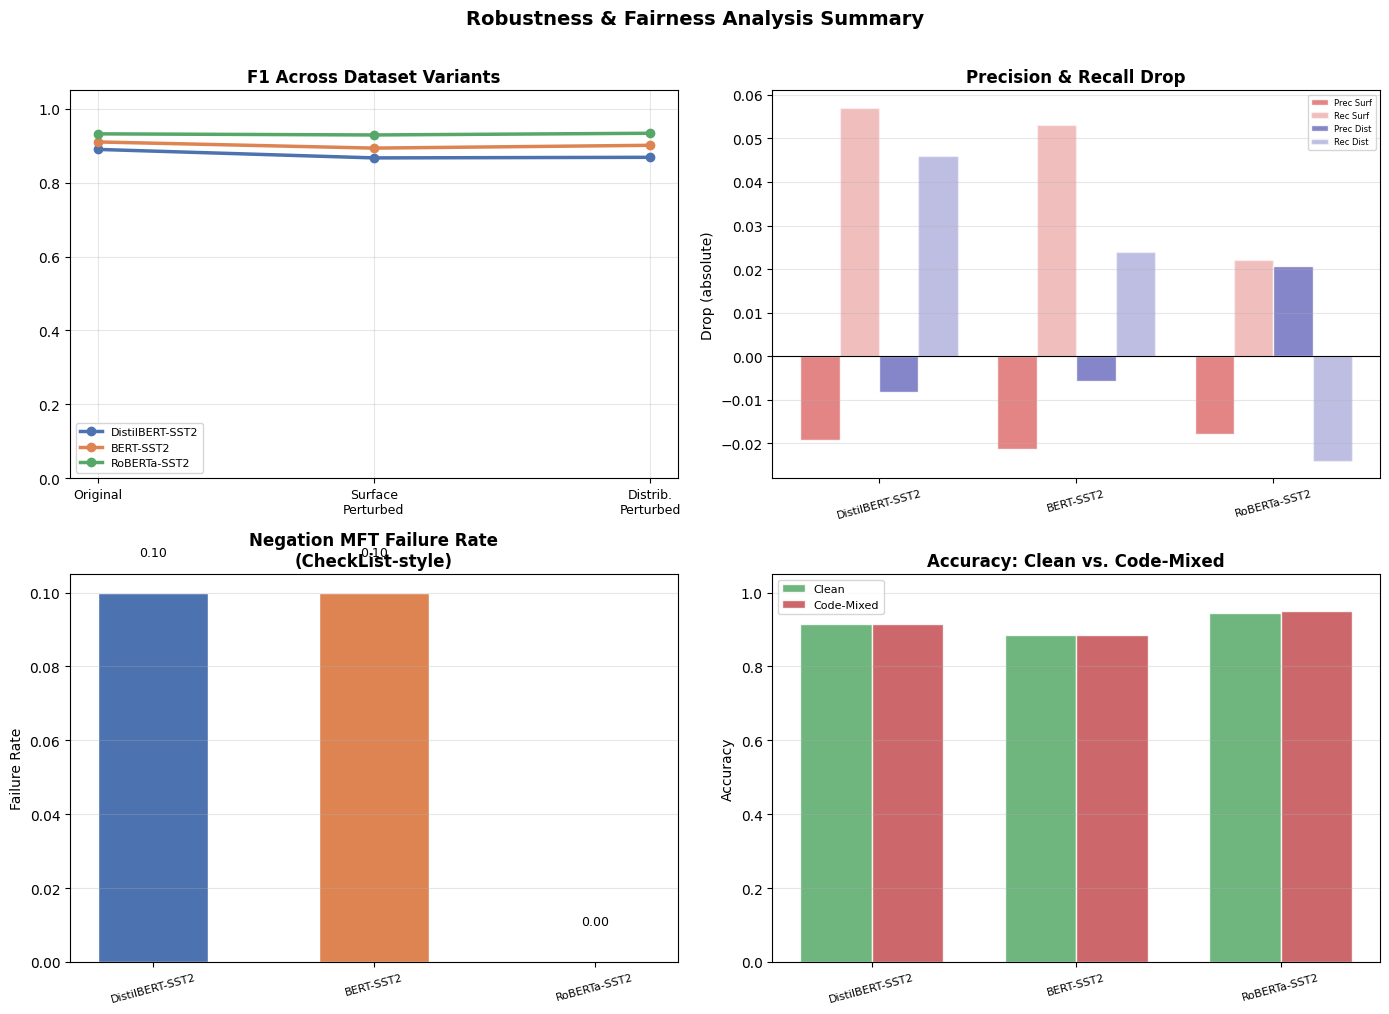

Saved fig7_summary.png


In [29]:
# --- Final summary visualization ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (1) F1 across variants
ax = axes[0, 0]
for cfg in MODEL_CONFIGS:
    mname = cfg['name']
    vals = [results_df[(results_df['Model']==mname) & (results_df['Dataset']==d)]['F1'].values[0]
            for d in DATASET_ORDER]
    ax.plot(DATASET_ORDER, vals, marker='o', label=mname, color=MODEL_COLORS[mname], linewidth=2.5)
ax.set_title('F1 Across Dataset Variants', fontweight='bold')
ax.set_ylim(0, 1.05)
ax.set_xticklabels(['Original', 'Surface\nPerturbed', 'Distrib.\nPerturbed'], fontsize=9)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# (2) Precision & Recall drop
ax = axes[0, 1]
model_names_plot = [c['name'] for c in MODEL_CONFIGS]
x_pos = np.arange(len(MODEL_CONFIGS))
w = 0.2
for j, (pert, color) in enumerate([('Surface-Perturbed', '#E07070'), ('Distributional-Perturbed', '#7070C0')]):
    prec_drops = [drop_df[(drop_df['Model']==m) & (drop_df['Perturbation']==pert)]['Precision Drop'].values[0] for m in model_names_plot]
    rec_drops  = [drop_df[(drop_df['Model']==m) & (drop_df['Perturbation']==pert)]['Recall Drop'].values[0]    for m in model_names_plot]
    offset = j * (2 * w) - 1.5 * w
    ax.bar(x_pos + offset,       prec_drops, w, label=f'Prec {pert[:4]}', color=color, alpha=0.85, edgecolor='white')
    ax.bar(x_pos + offset + w,   rec_drops,  w, label=f'Rec {pert[:4]}',  color=color, alpha=0.45, edgecolor='white')
ax.set_title('Precision & Recall Drop', fontweight='bold')
ax.set_ylabel('Drop (absolute)')
ax.set_xticks(x_pos)
ax.set_xticklabels(model_names_plot, rotation=15, fontsize=8)
ax.axhline(0, color='black', linewidth=0.8)
ax.legend(fontsize=6)
ax.grid(axis='y', alpha=0.3)

# (3) Negation failure rates
ax = axes[1, 0]
bars = ax.bar(neg_results_df['Model'], neg_results_df['Failure Rate'],
              color=[MODEL_COLORS[m] for m in neg_results_df['Model']], edgecolor='white', width=0.5)
ax.set_title('Negation MFT Failure Rate\n(CheckList-style)', fontweight='bold')
ax.set_ylabel('Failure Rate')
ax.set_xticklabels(neg_results_df['Model'], rotation=15, fontsize=8)
ax.grid(axis='y', alpha=0.3)
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{bar.get_height():.2f}', ha='center', fontsize=9)

# (4) Code-mixed accuracy drop
ax = axes[1, 1]
x = np.arange(len(MODEL_CONFIGS))
w = 0.35
ax.bar(x - w/2, cm_df['Accuracy (Clean)'], w, label='Clean', color='#55A868', alpha=0.85, edgecolor='white')
ax.bar(x + w/2, cm_df['Accuracy (Code-Mixed)'], w, label='Code-Mixed', color='#C44E52', alpha=0.85, edgecolor='white')
ax.set_title('Accuracy: Clean vs. Code-Mixed', fontweight='bold')
ax.set_ylabel('Accuracy')
ax.set_xticks(x)
ax.set_xticklabels(cm_df['Model'], rotation=15, fontsize=8)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

fig.suptitle('Robustness & Fairness Analysis Summary', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig7_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig7_summary.png')

In [30]:
# --- Save all results to CSV for reproducibility ---
results_df.to_csv('results_main.csv', index=False)
drop_df.to_csv('results_f1_drop.csv', index=False)
flip_df.to_csv('results_flip_rates.csv', index=False)
neg_results_df.to_csv('results_negation_mft.csv', index=False)
cm_df.to_csv('results_codemix.csv', index=False)

# Save dataset variants (first 200 rows for submission)
df_orig.head(200).to_csv('dataset_original_sample.csv', index=False)
df_surface.head(200).to_csv('dataset_surface_perturbed_sample.csv', index=False)
df_distrib.head(200).to_csv('dataset_distributional_perturbed_sample.csv', index=False)

print('All results and dataset samples saved.')
print('\nOutput files:')
import os
for f in sorted(os.listdir('.')):
    if f.endswith('.csv') or f.endswith('.png'):
        size = os.path.getsize(f)
        print(f'  {f:55s} {size:>8,} bytes')

All results and dataset samples saved.

Output files:
  IMDB Dataset.csv                                        66,212,309 bytes
  dataset_distributional_perturbed_sample.csv              278,621 bytes
  dataset_original_sample.csv                              272,468 bytes
  dataset_surface_perturbed_sample.csv                     273,059 bytes
  fig1_performance_across_variants.png                      72,762 bytes
  fig2_f1_heatmap.png                                       51,376 bytes
  fig3_f1_drop_bar.png                                      44,915 bytes
  fig4_gender_bias.png                                      41,976 bytes
  fig5_demographic_bias.png                                 58,658 bytes
  fig6_confusion_matrices.png                               70,800 bytes
  fig7_summary.png                                         136,809 bytes
  results_codemix.csv                                          143 bytes
  results_f1_drop.csv                                          759 b